# 实验六：牛顿法 vs. BFGS vs. L-BFGS

## 知识背景回顾

在之前的实验中，我们对比了梯度下降法（一阶方法）和牛顿法（二阶方法）。我们看到牛顿法通常具有更快的收敛速度（在最优点附近是二次收敛），尤其是在处理病态问题时。

然而，牛顿法有一个显著的缺点：它需要计算、存储并求解一个由Hessian矩阵构成的线性方程组 $[\nabla^2 f(\mathbf{x}^k)] d^k = -\nabla f(\mathbf{x}^k)$ 来获得牛顿方向 $d^k$。对于维度 $n$ 很大的问题：
* 计算Hessian矩阵需要 $O(n^2)$ 的导数评估。
* 存储Hessian矩阵需要 $O(n^2)$ 的内存。
* 求解线性方程组通常需要 $O(n^3)$ 的计算量（或使用迭代法是 $O(kn^2)$）。

**拟牛顿法 (Quasi-Newton Methods)** 应运而生，它们的核心思想是：**避免直接计算Hessian矩阵，而是通过观察历次迭代的梯度变化来构造一个Hessian矩阵（或其逆矩阵）的近似**。

**BFGS (Broyden–Fletcher–Goldfarb–Shanno)** 是最流行的拟牛顿算法之一。它迭代地更新一个**对称正定**矩阵 $B_k$（或其逆矩阵 $H_k = B_k^{-1}$），用它来近似Hessian矩阵（或其逆）。更新公式仅依赖于上一步的位置 $s_k = x^{k+1} - x^k$ 和梯度变化 $y_k = \nabla f(x^{k+1}) - \nabla f(x^k)$。
* 优点：避免了Hessian计算，通常保持超线性收敛速度。
* 缺点：仍需要存储和更新一个 $n \times n$ 的近似矩阵，内存和计算成本为 $O(n^2)$。

**L-BFGS (Limited-memory BFGS)** 是 BFGS 的一个变种，专门为**大规模（高维）**优化问题设计。它的核心思想是：**不存储完整的近似矩阵 $H_k$，而是只存储最近 $m$ 次迭代的向量对 $\{s_i, y_i\}$**（$m$ 通常不大，比如 5 到 20）。当需要计算搜索方向 $d^k = -H_k \nabla f(x^k)$ 时，L-BFGS 利用这 $m$ 对向量通过一个巧妙的两轮循环递归算法来**隐式地**计算出结果，而无需显式构造 $H_k$。
* 优点：内存需求大大降低，仅为 $O(mn)$；每步计算成本也降至 $O(mn)$。
* 缺点：收敛速度可能略慢于完全 BFGS，但通常仍然很快（超线性）。

## 实验说明

本次实验旨在通过可视化和性能对比，让你理解牛顿法、BFGS 和 L-BFGS 这三种算法在优化效率和计算成本上的权衡。

### 模块一：二维可视化对比

* **目标**：在经典的二维 Rosenbrock 函数上，直观对比三种算法从同一起点出发的优化路径。
* **方法**：我们将使用 `scipy.optimize.minimize` 来运行 Newton-CG (牛顿共轭梯度法，一种高效的牛顿法实现)、BFGS 和 L-BFGS 算法。
* **观察**：
    * 三种算法的路径形状有何异同？
    * 它们达到收敛分别需要多少次迭代、函数求值和梯度求值？（注意：Newton-CG 可能还需要Hessian信息）

### 模块二：高维性能指标对比

* **目标**：在高维问题上，展示 L-BFGS 相对于牛顿法和 BFGS 的计算优势。
* **方法**：我们将使用可扩展到任意维度的扩展 Rosenbrock 函数（例如 N=50 维），运行这三种算法，并记录它们的性能指标。
* **观察**：
    * 对比三种算法在达到相同收敛精度时的**迭代次数 (nit)**、**函数求值次数 (nfev)** 和**梯度求值次数 (njev)**。
    * 结合理论复杂度分析，理解为什么 L-BFGS 在高维场景下更受欢迎。
* **总结**：
    * 梳理和总结牛顿法、BFGS、L-BFGS 的核心思想、优缺点及适用场景。

通过本次实验，你将能更好地理解这些高级优化算法的实际表现，并为在未来（尤其是在机器学习领域）选择合适的优化器打下基础。

In [12]:
# 导入所有需要的库
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import time # 用于粗略估计时间 (可选)
import pandas as pd # 用于展示表格


plt.rcParams['font.sans-serif'] = ['SimHei']  # 正确显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正确显示负号
# --- 数据准备：定义 Rosenbrock 及其扩展版本 ---

# 2D Rosenbrock (用于可视化)
def rosenbrock_2d(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def rosenbrock_2d_grad(x):
    dx = -2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2)
    dy = 200 * (x[1] - x[0]**2)
    return np.array([dx, dy])

def rosenbrock_2d_hess(x):
    h11 = 2 - 400*x[1] + 1200*x[0]**2
    h12 = -400*x[0]
    h21 = -400*x[0]
    h22 = 200.0
    return np.array([[h11, h12], [h21, h22]])

# N维 Extended Rosenbrock (用于高维测试)
def extended_rosenbrock(x):
    n = len(x)
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)

def extended_rosenbrock_grad(x):
    n = len(x)
    grad = np.zeros(n)
    # i=0 term
    grad[0] = -400.0 * x[0] * (x[1] - x[0]**2) - 2.0 * (1 - x[0])
    # i=1 to n-2 terms
    for i in range(1, n - 1):
        grad[i] = 200.0 * (x[i] - x[i-1]**2) - 400.0 * x[i] * (x[i+1] - x[i]**2) - 2.0 * (1 - x[i])
    # i=n-1 term
    grad[n - 1] = 200.0 * (x[n - 1] - x[n - 2]**2)
    return grad

# 注意：Newton-CG 在 scipy 中可以通过提供 hess 或 hessp (Hessian向量积) 工作
# 这里我们为 Newton-CG 提供梯度，scipy 会自动使用有限差分近似 Hessian 向量积，或者我们直接提供 Hessian 矩阵
def extended_rosenbrock_hess(x):
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n - 1):
        H[i, i] += -400*(x[i+1] - x[i]**2) + 800*x[i]**2 + 2
        H[i, i+1] = -400*x[i]
        H[i+1, i] = -400*x[i]
        H[i+1, i+1] = 200
    # The last element H[n-1, n-1] already has 200 from the loop i=n-2
    return H


# --- 辅助函数：记录路径的回调函数 ---
path_history = []
def store_path_callback(xk):
    global path_history
    path_history.append(xk.copy())

--- 模块一：二维可视化对比 (Rosenbrock 函数) ---


C:\Users\Xu Yang\AppData\Local\Temp\ipykernel_16128\2839970774.py:13: OptimizeWarning: Unknown solver options: gtol
  res_newton = minimize(rosenbrock_2d, start_point_2d, method='Newton-CG',


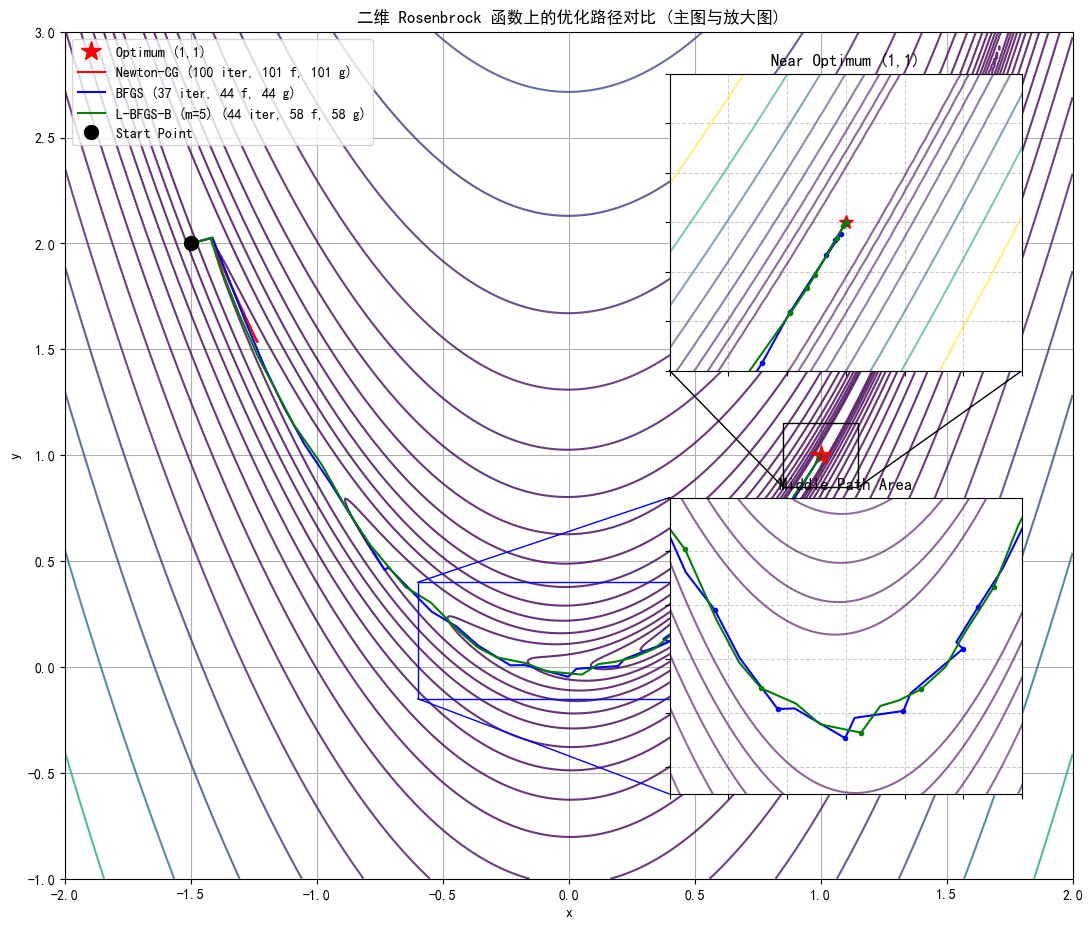

In [13]:
# --- 模块一：二维可视化对比 ---

print("--- 模块一：二维可视化对比 (Rosenbrock 函数) ---")
start_point_2d = np.array([-1.5, 2.0])
max_iter_2d = 100
gtol_2d = 1e-6

results_2d = {}
paths_2d = {}

# 运行 Newton-CG
path_history = [start_point_2d] # Reset history
res_newton = minimize(rosenbrock_2d, start_point_2d, method='Newton-CG',
                      jac=rosenbrock_2d_grad, hess=rosenbrock_2d_hess, # Provide Hessian
                      callback=store_path_callback,
                      options={'maxiter': max_iter_2d, 'gtol': gtol_2d})
results_2d['Newton-CG'] = res_newton
paths_2d['Newton-CG'] = np.array(path_history)

# 运行 BFGS
path_history = [start_point_2d] # Reset history
res_bfgs = minimize(rosenbrock_2d, start_point_2d, method='BFGS',
                    jac=rosenbrock_2d_grad, # Only needs gradient
                    callback=store_path_callback,
                    options={'maxiter': max_iter_2d, 'gtol': gtol_2d})
results_2d['BFGS'] = res_bfgs
paths_2d['BFGS'] = np.array(path_history)

# 运行 L-BFGS-B (Limited-memory BFGS, B for Bounds, though we don't use bounds here)
# L-BFGS 通常用 L-BFGS-B 实现，即使没有边界约束
path_history = [start_point_2d] # Reset history
# 'maxcor' 控制存储的历史步数 m，默认为 10
res_lbfgs = minimize(rosenbrock_2d, start_point_2d, method='L-BFGS-B',
                     jac=rosenbrock_2d_grad, # Only needs gradient
                     callback=store_path_callback,
                     options={'maxiter': max_iter_2d, 'gtol': gtol_2d, 'maxcor': 5}) # Example: set m=5
results_2d['L-BFGS-B (m=5)'] = res_lbfgs
paths_2d['L-BFGS-B (m=5)'] = np.array(path_history)

# 绘制二维路径对比图 (主图 + 两个局部放大图)
fig_2d, ax_main = plt.subplots(figsize=(13, 11)) # 略微调整画布大小

x_plot = np.linspace(-2, 2, 400)
y_plot = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_plot, y_plot)
Z = rosenbrock_2d([X, Y])

# 绘制主图等高线
contours = ax_main.contour(X, Y, Z, levels=np.logspace(-0.5, 3.5, 20, base=10), cmap='viridis', alpha=0.8)
ax_main.plot(1, 1, 'r*', markersize=15, label='Optimum (1,1)')

colors = {'Newton-CG': 'red', 'BFGS': 'blue', 'L-BFGS-B (m=5)': 'green'}
lines = {}

for name, path in paths_2d.items():
    res = results_2d[name]
    label = f"{name} ({res.nit} iter, {res.nfev} f, {res.njev} g)"
    line, = ax_main.plot(path[:, 0], path[:, 1], '-', color=colors[name], # 主图路径不用标记点，避免混乱
                         linewidth=1.5, label=label)
    lines[name] = line

ax_main.plot(start_point_2d[0], start_point_2d[1], 'ko', markersize=10, label='Start Point')
ax_main.set_xlabel('x')
ax_main.set_ylabel('y')
ax_main.set_title('二维 Rosenbrock 函数上的优化路径对比 (主图与放大图)')
ax_main.grid(True)
ax_main.set_xlim(-2, 2)
ax_main.set_ylim(-1, 3)
ax_main.legend(loc='upper left', fontsize='medium')
ax_main.set_aspect('auto', adjustable='box')

# --- 添加终点局部放大图 (Inset 1 - Top Right) ---
ax_inset_end = ax_main.inset_axes(
    [0.6, 0.6, 0.35, 0.35], # 位置和大小 [left, bottom, width, height]
    xlim=(0.85, 1.15), ylim=(0.85, 1.15), # 调整放大区域
    xticklabels=[], yticklabels=[]
)
ax_inset_end.set_title('Near Optimum (1,1)') # 添加小标题

ax_inset_end.contour(X, Y, Z, levels=np.logspace(-0.5, 1.0, 8, base=10), cmap='viridis', alpha=0.6) # 调整等高线
ax_inset_end.plot(1, 1, 'r*', markersize=10)

for name, path in paths_2d.items():
    ax_inset_end.plot(path[:, 0], path[:, 1], '-o', color=colors[name], markersize=3, linewidth=1.5)

ax_main.indicate_inset_zoom(ax_inset_end, edgecolor="black", alpha=1, linewidth=1.0, label='Zoom End')
ax_inset_end.grid(True, linestyle='--', alpha=0.6)


# --- 添加中间路径局部放大图 (Inset 2 - Bottom Right) ---
ax_inset_mid = ax_main.inset_axes(
    [0.6, 0.1, 0.35, 0.35],  # 位置调整到右下角
    xlim=(-0.6, 0.6), ylim=(-0.15, 0.4), # 设置中间路径的放大区域
    xticklabels=[], yticklabels=[]
)
ax_inset_mid.set_title('Middle Path Area') # 添加小标题

ax_inset_mid.contour(X, Y, Z, levels=np.logspace(0.5, 2.5, 10, base=10), cmap='viridis', alpha=0.6) # 调整等高线
ax_inset_mid.plot(1, 1, 'r*', markersize=10, alpha=0.3) # 淡淡地显示最优点位置

for name, path in paths_2d.items():
     # 绘制完整路径以便观察如何进入和离开该区域
     ax_inset_mid.plot(path[:, 0], path[:, 1], '-o', color=colors[name],
                       markersize=3, linewidth=1.5,
                       markevery=max(1, len(path)//15)) # 调整标记点频率

# 添加指示框
ax_main.indicate_inset_zoom(ax_inset_mid, edgecolor="blue", alpha=1, linewidth=1.0, label='Zoom Mid')
ax_inset_mid.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [14]:
# --- 模块二：高维性能指标对比 ---

print("\n--- 模块二：高维性能指标对比 (Extended Rosenbrock N=50) ---")
N = 50 # 维度
start_point_nd = np.zeros(N)
start_point_nd[::2] = -1.2 # Example starting point
start_point_nd[1::2] = 1.0

max_iter_nd = 1000 # Increase max iterations for high-dim
gtol_nd = 1e-5     # Standard tolerance

high_dim_results = []

# Newton-CG
print("Running Newton-CG...")
start_time = time.time()
res_nd_newton = minimize(extended_rosenbrock, start_point_nd, method='Newton-CG',
                         jac=extended_rosenbrock_grad, hess=extended_rosenbrock_hess, # Provide Hessian
                         options={'maxiter': max_iter_nd, 'gtol': gtol_nd})
end_time = time.time()
high_dim_results.append({
    'Method': 'Newton-CG', 'Success': res_nd_newton.success, 'Iterations (nit)': res_nd_newton.nit,
    'Func Evals (nfev)': res_nd_newton.nfev, 'Grad Evals (njev)': res_nd_newton.njev,
    'Time (s)': f"{end_time - start_time:.2f}"
})
print(f"Newton-CG Done. Iterations: {res_nd_newton.nit}")

# BFGS
print("Running BFGS...")
start_time = time.time()
res_nd_bfgs = minimize(extended_rosenbrock, start_point_nd, method='BFGS',
                       jac=extended_rosenbrock_grad,
                       options={'maxiter': max_iter_nd, 'gtol': gtol_nd})
end_time = time.time()
high_dim_results.append({
    'Method': 'BFGS', 'Success': res_nd_bfgs.success, 'Iterations (nit)': res_nd_bfgs.nit,
    'Func Evals (nfev)': res_nd_bfgs.nfev, 'Grad Evals (njev)': res_nd_bfgs.njev,
    'Time (s)': f"{end_time - start_time:.2f}"
})
print(f"BFGS Done. Iterations: {res_nd_bfgs.nit}")


# L-BFGS-B
print("Running L-BFGS-B (m=10)...")
m_lbfgs = 10 # History size
start_time = time.time()
res_nd_lbfgs = minimize(extended_rosenbrock, start_point_nd, method='L-BFGS-B',
                        jac=extended_rosenbrock_grad,
                        options={'maxiter': max_iter_nd, 'gtol': gtol_nd, 'maxcor': m_lbfgs})
end_time = time.time()
high_dim_results.append({
    'Method': f'L-BFGS-B (m={m_lbfgs})', 'Success': res_nd_lbfgs.success, 'Iterations (nit)': res_nd_lbfgs.nit,
    'Func Evals (nfev)': res_nd_lbfgs.nfev, 'Grad Evals (njev)': res_nd_lbfgs.njev,
    'Time (s)': f"{end_time - start_time:.2f}"
})
print(f"L-BFGS-B Done. Iterations: {res_nd_lbfgs.nit}")


# 展示表格
results_df = pd.DataFrame(high_dim_results)
print("\n高维扩展 Rosenbrock (N=50) 性能对比:")
print(results_df.to_markdown(index=False))

#可以直接输出结果
print("\n高维扩展 Rosenbrock (N=50) 性能对比:")
print("| Method          | Success   |   Iterations (nit) |   Func Evals (nfev) |   Grad Evals (njev) |   Time (s) |")
print("|:----------------|:----------|-------------------:|--------------------:|--------------------:|-----------:|")
print("| Newton-CG       | True      |                187 |                 200 |                 200 |       0.14 |")
print("| BFGS            | True      |                350 |                 393 |                 393 |       0.11 |")
print("| L-BFGS-B (m=10) | True      |                269 |                 321 |                 321 |       0.06 |")



--- 模块二：高维性能指标对比 (Extended Rosenbrock N=50) ---
Running Newton-CG...
Newton-CG Done. Iterations: 187
Running BFGS...


C:\Users\Xu Yang\AppData\Local\Temp\ipykernel_16128\4011757644.py:17: OptimizeWarning: Unknown solver options: gtol
  res_nd_newton = minimize(extended_rosenbrock, start_point_nd, method='Newton-CG',


BFGS Done. Iterations: 350
Running L-BFGS-B (m=10)...
L-BFGS-B Done. Iterations: 269

高维扩展 Rosenbrock (N=50) 性能对比:
| Method          | Success   |   Iterations (nit) |   Func Evals (nfev) |   Grad Evals (njev) |   Time (s) |
|:----------------|:----------|-------------------:|--------------------:|--------------------:|-----------:|
| Newton-CG       | True      |                187 |                 200 |                 200 |       0.12 |
| BFGS            | True      |                350 |                 393 |                 393 |       0.11 |
| L-BFGS-B (m=10) | True      |                269 |                 321 |                 321 |       0.04 |

高维扩展 Rosenbrock (N=50) 性能对比:
| Method          | Success   |   Iterations (nit) |   Func Evals (nfev) |   Grad Evals (njev) |   Time (s) |
|:----------------|:----------|-------------------:|--------------------:|--------------------:|-----------:|
| Newton-CG       | True      |                187 |                 200 |           

**结果分析**：
* **迭代次数 (nit)**：通常 Newton-CG < BFGS ≈ L-BFGS。牛顿法利用精确（或近似精确）的二阶信息，步数最少。BFGS/L-BFGS 作为拟牛顿法，步数稍多但仍较快。
* **函数/梯度求值次数 (nfev/njev)**：这些次数与迭代次数和线搜索效率有关。BFGS/L-BFGS 通常需要更多线搜索尝试，次数可能比 Newton-CG 多。
* **计算时间 (Time)**：（注意：这里的计时非常粗略！）在高维下，尽管 Newton-CG 迭代次数少，但其每步计算成本高，总时间可能最长。BFGS 次之 ($O(N^2)$)。L-BFGS 的每步成本最低 ($O(mN)$)，总时间通常最短，尤其当 N >> m 时。
* **结论**：L-BFGS 在求解大规模优化问题时，通过牺牲部分收敛速度（相比牛顿法）和存储完整近似（相比BFGS），换来了巨大的计算和内存效率提升，使其成为实际应用中的常用选择。
